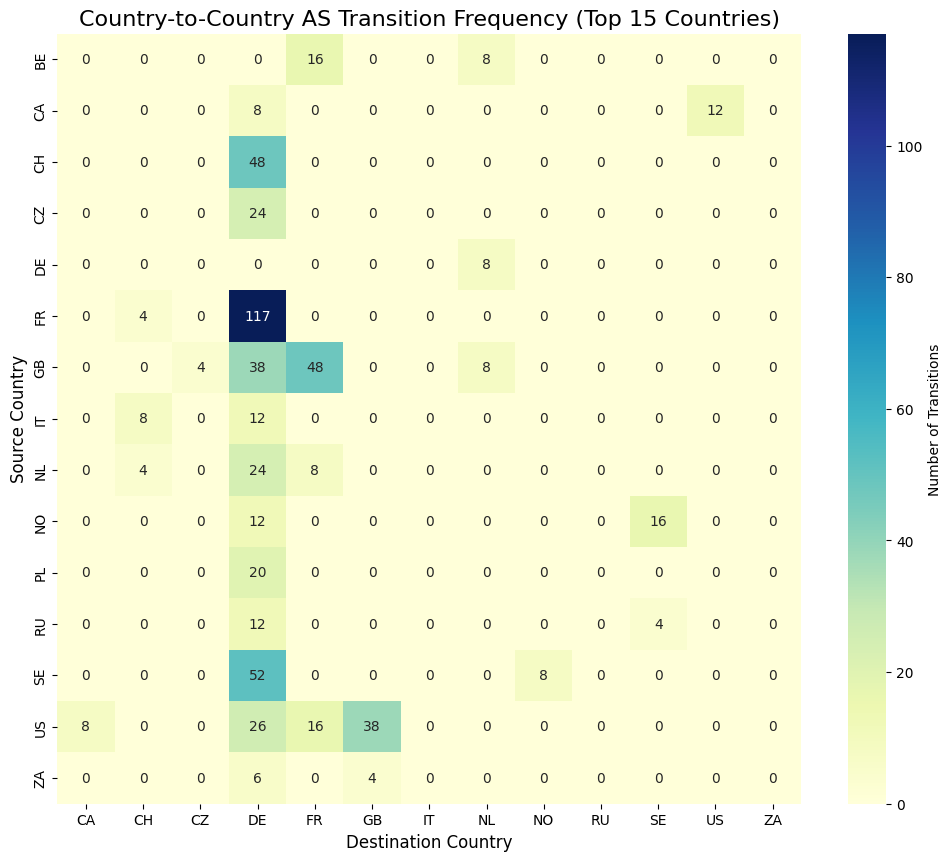

In [8]:
import csv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

input_file = "all_hops.csv"

country_transitions = []

prev_prb_id = None
c1 = None
c2 = None

with open(input_file, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)

    for row in reader:
        prb_id = row["prb_id"]
        country = row["country"]

        # Skip rows without country info
        if country is None or country.strip() == "":
            continue

        # If new probe starts - reset state
        if prb_id != prev_prb_id:
            prev_prb_id = prb_id
            c1 = None
            c2 = None

        if c1 is None and c2 is None:
            c1 = country
        elif c1 is not None and c2 is None:
            c2 = country

            # Only keep real transitions (no DE → DE)
            if c1 != c2:
                country_transitions.append((c1, c2))

            # Shift window
            c1 = c2
            c2 = None

#--------------------------------------------------------
# 5. Create a Transition Matrix
ct_df = pd.DataFrame(country_transitions, columns=['Source', 'Target'])
ct_matrix = pd.crosstab(ct_df['Source'], ct_df['Target'])

# 6. Filter for the Top 15 Countries
top_countries = ct_df['Source'].value_counts().head(15).index
ct_matrix_filtered = ct_matrix.loc[
    ct_matrix.index.isin(top_countries), 
    ct_matrix.columns.isin(top_countries)
]

# 7. Generate the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(ct_matrix_filtered, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Number of Transitions'})

plt.title("Country-to-Country AS Transition Frequency (Top 15 Countries)", fontsize=16)
plt.xlabel("Destination Country", fontsize=12)
plt.ylabel("Source Country", fontsize=12)

# Save and show
plt.savefig('country_transition_heatmap.png', bbox_inches='tight')
plt.show()